# 02_feature_engineering

**Логика построения признаков:**
1. Сначала вводим кластеризацию: угрозы → `threat_cluster`, предприятия → `infrastructure_cluster`
2. Агрегируем дневные события по каждой паре (infrastructure × threat)
3. Строим полный календарь дней и целевые метки
4. Добавляем временны́е, лаговые, роллинг-признаки и признаки по контексту (регион, тип)

**Входные файлы:**
- `data/interim/df_clean.parquet`

**Выходные файлы:**
- `data/interim/dataset_features.parquet` — итоговый датасет с признаками


## 1. Установка зависимостей и импорты

In [1]:
!pip install catboost -q


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path
from io import StringIO

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 5)

print("Импорты выполнены")

Импорты выполнены


## 2. Загрузка очищенных данных

In [3]:
# Ноутбуки в notebooks/, корень проекта — на уровень выше
base_path = Path('..')

df = pd.read_parquet(base_path / 'data/processed/df_clean.parquet')

print(f"Форма датафрейма: {df.shape}")
print(f"Столбцы: {df.columns.tolist()}")
display(df.head(3))

Форма датафрейма: (1948, 21)
Столбцы: ['Тип предприятия', 'Код предприятия', 'Количество хостов', 'Код реализованной угрозы', 'Успех', 'Регион размещения предприятия', 'Региональное время', 'Идентификатор УБИ', 'Наименование УБИ', 'Описание', 'Источник угрозы (характеристика и потенциал нарушителя)', 'Объект воздействия', 'Нарушение конфиденциальности', 'Нарушение целостности', 'Нарушение доступности', 'Дата включения угрозы в БнД УБИ', 'Дата последнего изменения данных', 'date', 'year_month', 'day_of_week', 'hour']


,Тип предприятия,Код предприятия,Количество хостов,Код реализованной угрозы,Успех,Регион размещения предприятия,Региональное время,Идентификатор УБИ,Наименование УБИ,Описание,...,Объект воздействия,Нарушение конфиденциальности,Нарушение целостности,Нарушение доступности,Дата включения угрозы в БнД УБИ,Дата последнего изменения данных,date,year_month,day_of_week,hour
0,НКО,1825,251,190,1,Республика Марий,2024-04-02 07:47:00,190,Угроза внедрения вредоносного кода за счет пос...,Угроза заключается в возможности осуществления...,...,Сетевое программное обеспечение,1,1,1,2016-10-21,2019-02-08,2024-04-02,2024-04,1,7
1,химия,8936,378,152,1,Республика Адыгея,2023-03-03 05:13:00,152,Угроза удаления аутентификационной информации,Угроза заключается в возможности отказа легити...,...,"Системное программное обеспечение, микропрогра...",1,1,1,2015-03-20,2019-02-11,2023-03-03,2023-03,4,5
2,отели,8280,1432,7,0,Севастополь,2025-05-09 10:28:00,7,Угроза воздействия на программы с высокими при...,Угроза заключается в возможности повышения нар...,...,"Информационная система, виртуальная машина, се...",1,1,0,2015-03-20,2019-02-08,2025-05-09,2025-05,4,10


## 3. Кластеризация угроз (threat_cluster)

Вместо использования каждой из 227 угроз по отдельности, группируем их по тематическим кластерам.
Это уменьшает разреженность данных и позволяет модели учиться на более статистически значимых паттернах.

**Кластеры угроз:**
- 1 — Вредоносное ПО / Malware
- 2 — DDoS-атаки
- 3 — Brute Force / Подбор паролей
- 4 — Социальная инженерия / Фишинг
- 5 — Эксплуатация уязвимостей
- 6 — Инсайдерские угрозы

Разметка выполнена экспертно** на основе описаний угроз ФСТЭК.


In [4]:
# Таблица сопоставления: код угрозы → кластер (на основе экспертного анализа БнД УБИ ФСТЭК)
# Формат: код_угрозы;кластер
CLUSTER_DATA = """код_угрозы;кластер
1;3
2;5
3;6
4;1
5;1
6;4
7;4
8;6
9;1
10;4
11;5
12;2
13;1
14;3
15;6
16;5
17;5
18;1
19;5
20;2
21;2
22;3
23;1
24;1
25;6
26;6
27;1
28;6
29;3
30;2
31;2
32;1
33;2
34;6
35;1
36;2
37;6
38;3
39;1
40;2
41;5
42;5
43;3
44;4
45;4
46;5
47;3
48;4
49;6
50;6
51;3
52;2
53;1
54;2
55;5
56;2
57;6
58;3
59;3
60;3
61;3
62;5
63;2
64;2
65;2
66;2
67;2
68;4
69;5
70;2
71;6
72;1
73;5
74;3
75;5
76;4
77;4
78;4
79;4
80;4
81;6
82;3
83;5
84;6
85;5
86;3
87;1
88;6
89;6
90;3
91;3
92;1
93;6
94;4
95;4
96;2
97;6
98;5
99;5
100;2
101;6
102;4
103;5
104;5
105;3
106;3
107;1
108;4
109;2
110;3
111;5
112;4
113;3
114;4
115;5
116;5
117;4
118;4
119;4
120;4
121;4
122;4
123;1
124;6
125;5
126;5
127;2
128;5
129;1
130;5
131;5
132;5
133;5
134;2
135;6
136;6
137;2
138;2
139;1
140;3
141;2
142;2
143;3
144;1
145;2
146;4
147;4
148;3
149;4
150;1
151;5
152;3
153;3
154;1
155;3
156;2
157;1
158;3
159;2
160;1
161;3
162;4
163;4
164;1
165;2
166;2
167;3
168;2
169;4
170;3
171;3
172;3
173;3
174;5
175;5
176;3
177;2
178;4
179;6
180;1
181;5
182;1
183;5
184;6
185;2
186;5
187;4
188;4
189;4
190;5
191;4
192;2
193;6
194;1
195;1
196;2
197;6
198;3
199;5
200;6
201;6
202;4
203;1
204;4
205;3
206;1
207;1
208;3
209;1
210;4
211;2
212;4
213;4
214;2
215;6
216;4
217;4
218;1
219;1
220;1
221;1
222;1
223;4
224;4
225;4
226;6
227;6"""

df_clusters = pd.read_csv(StringIO(CLUSTER_DATA), sep=';')

# Присоединяем кластер к инцидентам
df = df.merge(
    df_clusters,
    how='left',
    left_on='Код реализованной угрозы',
    right_on='код_угрозы'
)

# Убираем строки без кластера (угрозы не из справочника)
before = len(df)
df = df.dropna(subset=['код_угрозы']).copy()
df['threat_cluster'] = df['кластер'].astype(int)

print(f"Удалено строк без кластера угрозы: {before - len(df)}")
print(f"Распределение по кластерам угроз:")
print(df['threat_cluster'].value_counts().sort_index())

Удалено строк без кластера угрозы: 0
Распределение по кластерам угроз:
threat_cluster
1    292
2    331
3    325
4    415
5    317
6    268
Name: count, dtype: int64


## 4. Кластеризация предприятий (infrastructure_cluster)

Тип предприятия определяет его профиль уязвимостей и поведение атакующих.
Мы группируем отрасли в 4 кластера:

| Кластер | Название | Примеры отраслей |
|---------|----------|-----------------|
| 1 | Digital-Native | IT, телеком, реклама, маркетинг |
| 2 | Industrial IoT | Машиностроение, металлургия, энергетика |
| 3 | Data-Sensitive | Медицина, образование, НКО |
| 4 | Service-Oriented | Розница, отели, консалтинг |


In [5]:
# Сопоставление отраслей с кластерами
infrastructure_clusters = {
    1: [  # Digital-Native — высокотехнологичные, высокая связность
        'информационные технологии', 'реклама', 'маркетинг',
        'телекоммуникации', 'системная интеграция'
    ],
    2: [  # Industrial IoT — промышленные, физические последствия
        'машиностроение', 'металлургия', 'химия',
        'добыча', 'энергетика', 'логистика'
    ],
    3: [  # Data-Sensitive — чувствительные персональные данные
        'медицина', 'фармацевтика', 'образование', 'НКО', 'безопасность'
    ],
    4: [  # Service-Oriented — сервисные, высокая текучесть клиентов
        'розничная торговля', 'отели', 'ресторанный бизнес',
        'консалтинг', 'автобизнес'
    ]
}

# Создаём плоский словарь: отрасль → номер кластера
industry_to_cluster = {}
for cluster_id, industries in infrastructure_clusters.items():
    for industry in industries:
        industry_to_cluster[industry] = cluster_id

df['infrastructure_cluster'] = df['Тип предприятия'].map(industry_to_cluster)

print("Распределение по кластерам инфраструктуры:")
print(df['infrastructure_cluster'].value_counts(dropna=False).sort_index())
print(f"\nДоля предприятий без кластера: {df['infrastructure_cluster'].isna().mean():.3f}")

Распределение по кластерам инфраструктуры:
infrastructure_cluster
1    446
2    550
3    505
4    447
Name: count, dtype: int64

Доля предприятий без кластера: 0.000


In [6]:
# Нормализуем типы — важно для join и group-by операций
df['infrastructure_cluster'] = df['infrastructure_cluster'].astype(str)
df['Тип предприятия'] = df['Тип предприятия'].astype(str)
df['Регион размещения предприятия'] = df['Регион размещения предприятия'].astype(str)

# Дата события (пол дня): убираем время, оставляем только дату
df['date'] = df['Региональное время'].dt.floor('D')

# Сортируем по ключу сегмента и времени
df = df.sort_values(['infrastructure_cluster', 'Региональное время']).reset_index(drop=True)

print(f"Форма датафрейма: {df.shape}")

Форма датафрейма: (1948, 25)


## 5. Дневная агрегация по сегментам

Модель работает на дневном горизонте: для каждой пары (infrastructure_cluster, threat_cluster)
за каждый день считаем:
- `incidents_count_day` — количество инцидентов
- `success_count_day` — количество успешных атак
- `had_incident_today` — бинарная метка: был ли хоть один инцидент в этот день


In [7]:
# Агрегация на уровне (кластер инфраструктуры, кластер угрозы, день)
daily_entity = (
    df.groupby(['infrastructure_cluster', 'threat_cluster', 'date'], as_index=False)
      .agg({
          'Тип предприятия': 'last',           # берём последний (для справки)
          'Регион размещения предприятия': 'last',
          'Количество хостов': 'last',          # последнее известное значение
          'Успех': 'sum',                        # суммарное число успешных атак за день
          'Региональное время': 'count'          # общее число инцидентов за день
      })
      .rename(columns={
          'Региональное время': 'incidents_count_day',
          'Успех': 'success_count_day'
      })
)

# Бинарный флаг: был ли хоть один инцидент в этот день
daily_entity['had_incident_today'] = (daily_entity['incidents_count_day'] > 0).astype(int)

print(f"Форма daily_entity: {daily_entity.shape}")
print(f"Доля дней с инцидентами: {daily_entity['had_incident_today'].mean():.3f}")
display(daily_entity.head(5))

Форма daily_entity: (1858, 9)
Доля дней с инцидентами: 1.000


,infrastructure_cluster,threat_cluster,date,Тип предприятия,Регион размещения предприятия,Количество хостов,success_count_day,incidents_count_day,had_incident_today
0,1,1,2023-01-25,телекоммуникации,Ямало-Ненецкий автономный округ,390,0,1,1
1,1,1,2023-03-16,информационные технологии,Чувашская Республика,1015,1,1,1
2,1,1,2023-03-17,маркетинг,Томская область,1559,0,1,1
3,1,1,2023-03-18,информационные технологии,Республика Хакасия,1774,0,1,1
4,1,1,2023-04-04,системная интеграция,Кировская область,819,0,1,1


## 6. Построение полного календаря

Чтобы временные признаки (лаги, скользящие суммы) работали корректно,
нужен непрерывный временной ряд для каждого сегмента.

Создаём cross-join: каждый сегмент × каждый день периода наблюдений.
Пропущенные дни (когда не было ни одного инцидента) заполняем нулями.


In [8]:
# Диапазон дат
min_date = daily_entity['date'].min()
max_date = daily_entity['date'].max()
all_dates = pd.date_range(min_date, max_date, freq='D')

print(f"Диапазон: {min_date.date()} → {max_date.date()}")
print(f"Всего дней: {len(all_dates)}")

# Уникальные сегменты с метаданными
entity_info = (
    df.sort_values('Региональное время')
      .groupby(['infrastructure_cluster', 'threat_cluster'], as_index=False)
      .agg({
          'Тип предприятия': 'last',
          'Регион размещения предприятия': 'last',
          'Количество хостов': 'last'
      })
)

print(f"\nУникальных сегментов (infra × threat): {len(entity_info)}")

# Строим полный календарь через cross-join (ключ=1)
calendar = (
    entity_info.assign(key=1)
    .merge(pd.DataFrame({'date': all_dates, 'key': 1}), on='key')
    .drop(columns='key')
)

print(f"Размер полного календаря: {calendar.shape}")

Диапазон: 2023-01-01 → 2026-01-01
Всего дней: 1097

Уникальных сегментов (infra × threat): 24
Размер полного календаря: (26328, 6)


In [9]:
# Присоединяем дневную активность, заполняем пропуски нулями
dataset = calendar.merge(
    daily_entity[['infrastructure_cluster', 'threat_cluster', 'date',
                  'incidents_count_day', 'success_count_day', 'had_incident_today']],
    on=['infrastructure_cluster', 'threat_cluster', 'date'],
    how='left'
)

# Нулевые значения для дней без инцидентов
dataset['incidents_count_day'] = dataset['incidents_count_day'].fillna(0).astype(int)
dataset['success_count_day'] = dataset['success_count_day'].fillna(0).astype(int)
dataset['had_incident_today'] = dataset['had_incident_today'].fillna(0).astype(int)

dataset = dataset.sort_values(
    ['infrastructure_cluster', 'threat_cluster', 'date']
).reset_index(drop=True)

print(f"Итоговый dataset: {dataset.shape}")
print(f"Доля дней с инцидентами: {dataset['had_incident_today'].mean():.4f}")
display(dataset.head(8))

Итоговый dataset: (26328, 9)
Доля дней с инцидентами: 0.0706


,infrastructure_cluster,threat_cluster,Тип предприятия,Регион размещения предприятия,Количество хостов,date,incidents_count_day,success_count_day,had_incident_today
0,1,1,маркетинг,Амурская область,1684,2023-01-01,0,0,0
1,1,1,маркетинг,Амурская область,1684,2023-01-02,0,0,0
2,1,1,маркетинг,Амурская область,1684,2023-01-03,0,0,0
3,1,1,маркетинг,Амурская область,1684,2023-01-04,0,0,0
4,1,1,маркетинг,Амурская область,1684,2023-01-05,0,0,0
5,1,1,маркетинг,Амурская область,1684,2023-01-06,0,0,0
6,1,1,маркетинг,Амурская область,1684,2023-01-07,0,0,0
7,1,1,маркетинг,Амурская область,1684,2023-01-08,0,0,0


## 7. Построение целевых переменных (target labels)

Формируем два горизонта прогнозирования:

- **target_next_24h** — будет ли хотя бы один инцидент завтра (следующие 24 ч)
- **target_next_7d** — будет ли хотя бы один инцидент в течение следующих 7 дней

Используем `shift(-k)` внутри каждой группы — это стандартный приём для временного forecasting.


In [10]:
# target_next_24h: инцидент завтра
# shift(-1) сдвигает значение «вперёд» — сегодня мы видим то, что было завтра
dataset['target_next_24h'] = (
    dataset.groupby(['infrastructure_cluster', 'threat_cluster'])['had_incident_today']
           .shift(-1)
)

# Удаляем последний день каждой группы (там target = NaN, т.к. будущего нет)
dataset = dataset.dropna(subset=['target_next_24h']).copy()
dataset['target_next_24h'] = dataset['target_next_24h'].astype(int)

print(f"Доля positives target_next_24h: {dataset['target_next_24h'].mean():.4f}")

Доля positives target_next_24h: 0.0705


In [11]:
# target_next_7d: был ли инцидент хотя бы в один из следующих 7 дней
# Берём максимум среди shift(-1), shift(-2), ..., shift(-7)
def make_future_target(group, source_col='had_incident_today', k=7):
    """
    Для каждой строки смотрим k следующих дней.
    Возвращаем 1, если хотя бы в один из них был инцидент.
    """
    s = group[source_col]
    # Создаём k смещённых столбцов
    future_cols = pd.concat([s.shift(-i) for i in range(1, k + 1)], axis=1)
    return future_cols.max(axis=1)  # любой из k дней = 1 → result = 1

dataset['target_next_7d'] = (
    dataset.groupby(['infrastructure_cluster', 'threat_cluster'], group_keys=False)
           .apply(make_future_target, source_col='had_incident_today', k=7)
)

# Удаляем последние 7 дней каждой группы (неполный горизонт)
dataset = dataset.dropna(subset=['target_next_7d']).copy()
dataset['target_next_7d'] = dataset['target_next_7d'].astype(int)

print(f"Доля positives target_next_24h: {dataset['target_next_24h'].mean():.4f}")
print(f"Доля positives target_next_7d:  {dataset['target_next_7d'].mean():.4f}")
print(f"\nРазмер датасета: {dataset.shape}")

Доля positives target_next_24h: 0.0705
Доля positives target_next_7d:  0.3994

Размер датасета: (26280, 11)


## 7b. Целевые переменные для регрессии и мультиклассовой классификации

Помимо бинарных меток добавляем:

### Регрессия — `days_until_next_attack`
Для каждого дня считаем **сколько дней осталось до следующего инцидента**.  
- Это время «обратного отсчёта» — 0 означает «инцидент именно сегодня», 1 — «завтра», и т.д.  
- Дни, для которых следующей атаки нет в горизонте наблюдений, заполняем `NaN` и удаляем при обучении.  
- Признак `days_until_next_attack` используется в `03_regression.ipynb`.

### Мультиклассовая классификация — `attack_window_class`
Разбиваем будущее на 5 временных окон:

| Класс | Описание | Смысл |
|-------|----------|-------|
| 0 | `next_1d` | Атака завтра (≤1 день) |
| 1 | `next_3d` | Атака в течение 2–3 дней |
| 2 | `next_7d` | Атака в течение 4–7 дней |
| 3 | `next_14d` | Атака в течение 8–14 дней |
| 4 | `no_attack_30d` | Атаки не ожидается в ближайшие 30 дней |

Это позволяет модели различать **срочность угрозы**, а не только её наличие.
Используется в `03_multiclass.ipynb`.


Распределение days_until_next_attack:
count    25935.00
mean        13.20
std         13.69
min          0.00
25%          3.00
50%          9.00
75%         18.00
max         90.00
Name: days_until_next_attack, dtype: float64
Пропущенных (за горизонтом): 345


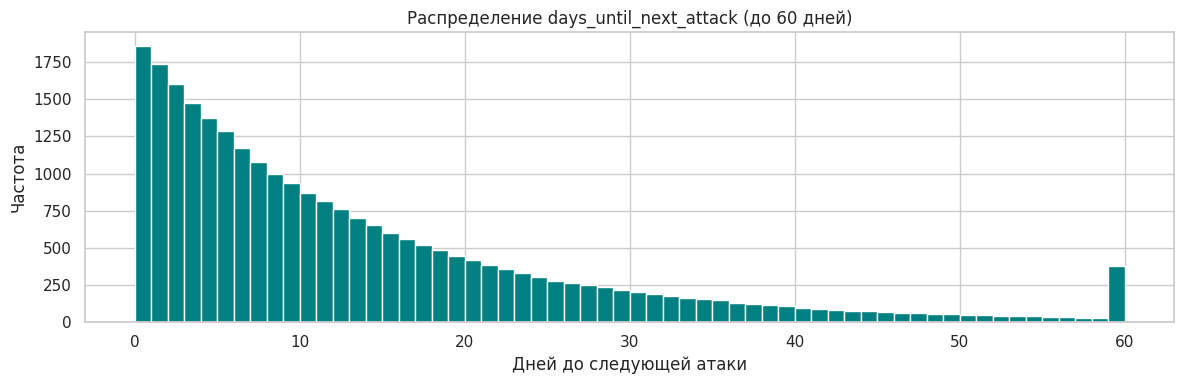

In [12]:
# ==============================================================
# Целевая переменная: days_until_next_attack (регрессия)
# ==============================================================
# Для каждого дня — количество дней до ближайшего следующего инцидента.
# Алгоритм: обходим ряд снизу вверх, запоминаем позицию следующего события.

def days_until_next_incident(series: pd.Series, max_horizon: int = 90) -> pd.Series:
    """
    Для каждой строки возвращает число дней до следующего инцидента.
    Если инцидента нет в пределах max_horizon — возвращает NaN.

    Args:
        series: бинарный ряд (1 = был инцидент)
        max_horizon: максимальный горизонт поиска (дней)
    """
    n = len(series)
    result = [np.nan] * n
    next_event_pos = None  # позиция следующего события (обход справа налево)

    arr = series.values
    # Идём с конца
    for i in range(n - 1, -1, -1):
        if arr[i] > 0:
            next_event_pos = i
        if next_event_pos is not None:
            dist = next_event_pos - i  # 0 — сегодня инцидент
            result[i] = dist if dist <= max_horizon else np.nan
        # else: NaN — ещё не видели ни одного инцидента впереди

    return pd.Series(result, index=series.index)


dataset['days_until_next_attack'] = (
    dataset.groupby(['infrastructure_cluster', 'threat_cluster'], group_keys=False)
           .apply(lambda g: days_until_next_incident(g['had_incident_today'], max_horizon=90))
)

print("Распределение days_until_next_attack:")
print(dataset['days_until_next_attack'].describe().round(2))
print(f"Пропущенных (за горизонтом): {dataset['days_until_next_attack'].isna().sum()}")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 4))
dataset['days_until_next_attack'].dropna().clip(upper=60).hist(bins=60, ax=ax, color='teal', edgecolor='white')
ax.set_title('Распределение days_until_next_attack (до 60 дней)')
ax.set_xlabel('Дней до следующей атаки')
ax.set_ylabel('Частота')
plt.tight_layout()
plt.show()


Распределение attack_window_class:
  Класс 0 (next_1d):   3,591 строк (13.7%)
  Класс 1 (next_3d):   3,082 строк (11.7%)
  Класс 2 (next_7d):   4,906 строк (18.7%)
  Класс 3 (next_14d):   5,731 строк (21.8%)
  Класс 4 (no_attack_30d):   8,970 строк (34.1%)


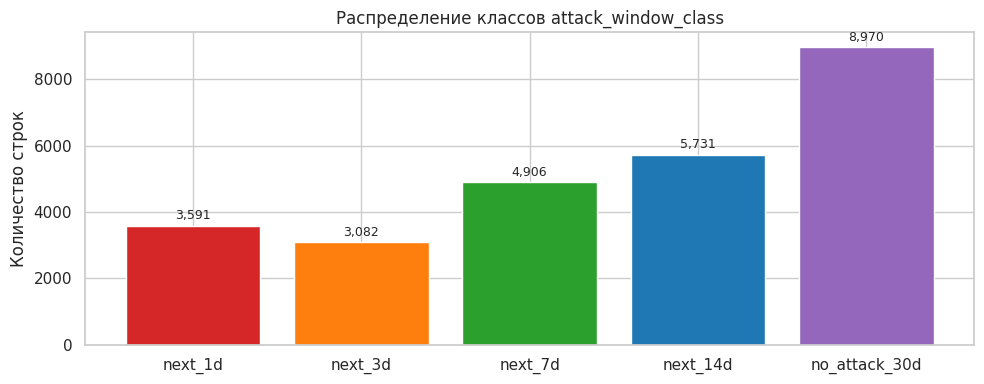

In [13]:
# ==============================================================
# Целевая переменная: attack_window_class (мультиклассовая классификация)
# ==============================================================
# Разбиваем days_until_next_attack на 5 классов срочности

def assign_attack_window(days_val):
    """
    Класс по временному окну до следующей атаки.

    0 — атака завтра (0 или 1 день)
    1 — атака за 2–3 дня
    2 — атака за 4–7 дней
    3 — атака за 8–14 дней
    4 — атака не ожидается (NaN или > 30 дней в горизонте)
    """
    if pd.isna(days_val):
        return 4
    d = int(days_val)
    if d <= 1:
        return 0   # «Атака завтра»
    elif d <= 3:
        return 1   # «В течение 3 дней»
    elif d <= 7:
        return 2   # «В течение недели»
    elif d <= 14:
        return 3   # «В течение 2 недель»
    else:
        return 4   # «Нет угрозы в 30-дневном горизонте»

dataset['attack_window_class'] = dataset['days_until_next_attack'].apply(assign_attack_window)

# Словарь классов для удобства
ATTACK_WINDOW_LABELS = {
    0: 'next_1d',
    1: 'next_3d',
    2: 'next_7d',
    3: 'next_14d',
    4: 'no_attack_30d'
}

print("Распределение attack_window_class:")
vc = dataset['attack_window_class'].value_counts().sort_index()
for cls, cnt in vc.items():
    pct = cnt / len(dataset) * 100
    print(f"  Класс {cls} ({ATTACK_WINDOW_LABELS[cls]}): {cnt:>7,} строк ({pct:.1f}%)")

# Визуализация
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd']
bars = ax.bar(
    [ATTACK_WINDOW_LABELS[i] for i in range(5)],
    [vc.get(i, 0) for i in range(5)],
    color=colors,
    edgecolor='white'
)
ax.set_title('Распределение классов attack_window_class')
ax.set_ylabel('Количество строк')
for bar, cnt in zip(bars, [vc.get(i, 0) for i in range(5)]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{cnt:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


## 8. Календарные признаки

Временны́е паттерны важны для ИБ: атаки чаще происходят в конце рабочей недели,
перед праздниками или в определённые месяцы.

**Два типа кодирования:**
- Линейные: `day_of_week`, `month`, `quarter` — для tree-based моделей
- Циклические (sin/cos): сохраняют периодичность — полезно для нейросетей и линейных моделей


In [14]:
# Линейные временные признаки
dataset['day_of_week'] = dataset['date'].dt.dayofweek   # 0=Пн, 6=Вс
dataset['day_of_month'] = dataset['date'].dt.day         # 1-31
dataset['month'] = dataset['date'].dt.month              # 1-12
dataset['quarter'] = dataset['date'].dt.quarter          # 1-4
dataset['year'] = dataset['date'].dt.year
dataset['is_weekend'] = (dataset['day_of_week'] >= 5).astype(int)  # Сб/Вс = 1

# Циклическое кодирование дня недели (период = 7)
dataset['dow_sin'] = np.sin(2 * np.pi * dataset['day_of_week'] / 7)
dataset['dow_cos'] = np.cos(2 * np.pi * dataset['day_of_week'] / 7)

# Циклическое кодирование месяца (период = 12)
dataset['month_sin'] = np.sin(2 * np.pi * dataset['month'] / 12)
dataset['month_cos'] = np.cos(2 * np.pi * dataset['month'] / 12)

print("Созданы календарные признаки:")
cal_features = ['day_of_week', 'day_of_month', 'month', 'quarter', 'year',
                'is_weekend', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']
print(cal_features)

Созданы календарные признаки:
['day_of_week', 'day_of_month', 'month', 'quarter', 'year', 'is_weekend', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']


## 9. Лаговые признаки (lag features)

Лаги позволяют модели «видеть» прошлое: что происходило 1, 2, 3 дня назад.

**Важно:** используем `shift(+k)` (в прошлое), а не будущее — это предотвращает утечку данных (data leakage).


In [15]:
# Группируем по сегменту — все лаги считаются внутри группы
grp = dataset.groupby(['infrastructure_cluster', 'threat_cluster'])

# Лаги для количества инцидентов
dataset['lag_inc_1d'] = grp['incidents_count_day'].shift(1).fillna(0)
dataset['lag_inc_2d'] = grp['incidents_count_day'].shift(2).fillna(0)
dataset['lag_inc_3d'] = grp['incidents_count_day'].shift(3).fillna(0)

# Лаги для успешных атак
dataset['lag_success_1d'] = grp['success_count_day'].shift(1).fillna(0)
dataset['lag_success_2d'] = grp['success_count_day'].shift(2).fillna(0)

print("Созданы лаговые признаки:")
lag_features = ['lag_inc_1d', 'lag_inc_2d', 'lag_inc_3d', 'lag_success_1d', 'lag_success_2d']
print(lag_features)
print(f"\nПример для первого сегмента:")
display(dataset.groupby(['infrastructure_cluster', 'threat_cluster']).get_group(
    dataset.groupby(['infrastructure_cluster', 'threat_cluster']).groups.__iter__().__next__()
)[['date', 'incidents_count_day', 'lag_inc_1d', 'lag_inc_2d', 'lag_inc_3d']].head(8))

Созданы лаговые признаки:
['lag_inc_1d', 'lag_inc_2d', 'lag_inc_3d', 'lag_success_1d', 'lag_success_2d']

Пример для первого сегмента:


,date,incidents_count_day,lag_inc_1d,lag_inc_2d,lag_inc_3d
0,2023-01-01,0,0.0,0.0,0.0
1,2023-01-02,0,0.0,0.0,0.0
2,2023-01-03,0,0.0,0.0,0.0
3,2023-01-04,0,0.0,0.0,0.0
4,2023-01-05,0,0.0,0.0,0.0
5,2023-01-06,0,0.0,0.0,0.0
6,2023-01-07,0,0.0,0.0,0.0
7,2023-01-08,0,0.0,0.0,0.0


## 10. Скользящие (rolling) признаки

Скользящие суммы/средние дают модели информацию о «разогреве» атак:
если за последние 7 дней было много инцидентов, вероятность завтрашнего выше.

**Функция `add_rolling`** — универсальная утилита, которую используют и этот ноутбук, и `03_model_training.ipynb`.
Она принимает датафрейм с уже отсортированными данными и добавляет rolling-признаки.


In [16]:
def add_rolling(df_part: pd.DataFrame) -> pd.DataFrame:
    """
    Добавляет скользящие признаки к датафрейму.

    Входные требования:
        - df_part отсортирован по ['infrastructure_cluster', 'threat_cluster', 'date']
        - столбцы 'incidents_count_day' и 'success_count_day' присутствуют

    Возвращает:
        df_part с новыми столбцами rolling-признаков.
    """
    df_part = df_part.copy()

    grp = df_part.groupby(['infrastructure_cluster', 'threat_cluster'])

    # --- Скользящие суммы инцидентов ---
    # shift(1) перед rolling — чтобы текущий день не входил в окно (no leakage)
    df_part['inc_3d_sum'] = (
        grp['incidents_count_day']
        .shift(1)
        .rolling(3, min_periods=1)
        .sum()
        .reset_index(drop=True)
        .fillna(0)
    )

    df_part['inc_7d_sum'] = (
        grp['incidents_count_day']
        .shift(1)
        .rolling(7, min_periods=1)
        .sum()
        .reset_index(drop=True)
        .fillna(0)
    )

    df_part['inc_30d_sum'] = (
        grp['incidents_count_day']
        .shift(1)
        .rolling(30, min_periods=1)
        .sum()
        .reset_index(drop=True)
        .fillna(0)
    )

    # --- Скользящие суммы успешных атак ---
    df_part['succ_7d_sum'] = (
        grp['success_count_day']
        .shift(1)
        .rolling(7, min_periods=1)
        .sum()
        .reset_index(drop=True)
        .fillna(0)
    )

    df_part['succ_30d_sum'] = (
        grp['success_count_day']
        .shift(1)
        .rolling(30, min_periods=1)
        .sum()
        .reset_index(drop=True)
        .fillna(0)
    )

    # --- Бинарные флаги активности ---
    df_part['had_incident_prev_1d'] = (df_part['lag_inc_1d'] > 0).astype(int)
    df_part['had_incident_prev_3d'] = (df_part['inc_3d_sum'] > 0).astype(int)
    df_part['had_incident_prev_7d'] = (df_part['inc_7d_sum'] > 0).astype(int)

    return df_part

# Применяем функцию к полному датасету
dataset = add_rolling(dataset)

rolling_features = [
    'inc_3d_sum', 'inc_7d_sum', 'inc_30d_sum',
    'succ_7d_sum', 'succ_30d_sum',
    'had_incident_prev_1d', 'had_incident_prev_3d', 'had_incident_prev_7d'
]
print("Созданы rolling-признаки:")
print(rolling_features)

Созданы rolling-признаки:
['inc_3d_sum', 'inc_7d_sum', 'inc_30d_sum', 'succ_7d_sum', 'succ_30d_sum', 'had_incident_prev_1d', 'had_incident_prev_3d', 'had_incident_prev_7d']


## 11. Время с последнего инцидента (days_since_last_*)

Этот признак кодирует «паузу между атаками»:
- Короткая пауза → высокая вероятность продолжения кампании
- Длинная пауза → возможно, атакующие сменили цель

`999` означает «ни разу не было инцидента в истории наблюдений».


In [17]:
def days_since_last_event(series: pd.Series) -> pd.Series:
    """
    Вычисляет для каждого дня, сколько дней прошло с последнего события (значение > 0).

    Алгоритм: итеративный обход — запоминаем индекс последнего ненулевого дня.
    Возвращает NaN для строк до первого события.
    """
    result = []
    last_day = None
    for i, val in enumerate(series):
        if last_day is None:
            result.append(np.nan)       # не видели ещё ни одного события
        else:
            result.append(i - last_day) # дней с последнего события
        if val > 0:
            last_day = i                # обновляем день последнего события
    return pd.Series(result, index=series.index)

# Дней с последнего инцидента
dataset['days_since_last_incident'] = (
    dataset.groupby(['infrastructure_cluster', 'threat_cluster'])['had_incident_today']
           .apply(days_since_last_event)
           .reset_index(level=[0, 1], drop=True)
)
dataset['days_since_last_incident'] = dataset['days_since_last_incident'].fillna(999)

# Флаг «сегодня был успешная атака» + дней с последней успешной атаки
dataset['had_success_today'] = (dataset['success_count_day'] > 0).astype(int)
dataset['days_since_last_success'] = (
    dataset.groupby(['infrastructure_cluster', 'threat_cluster'])['had_success_today']
           .apply(days_since_last_event)
           .reset_index(level=[0, 1], drop=True)
)
dataset['days_since_last_success'] = dataset['days_since_last_success'].fillna(999)

print("Признаки 'days_since_*' созданы")
print(f"\nСтатистика days_since_last_incident:")
print(dataset['days_since_last_incident'].describe().round(1))

Признаки 'days_since_*' созданы

Статистика days_since_last_incident:
count    26280.0
mean        29.3
std        121.2
min          1.0
25%          4.0
50%         10.0
75%         20.0
max        999.0
Name: days_since_last_incident, dtype: float64


## 11b. Признаки интенсивности и трендов (для регрессии и мультикласса)

Дополнительные признаки:

- **`avg_inter_attack_interval`** — средний исторический интервал между атаками (характеристика «ритма» атак)
- **`attack_rate_trend`** — тренд: растёт или снижается частота атак (разность rolling 7d и 30d)
- **`streak_active_days`** — число непрерывно активных дней подряд (текущая «серия» атак)
- **`streak_quiet_days`** — число непрерывно тихих дней (текущая «пауза»)
- **`success_ratio_7d`** — доля успешных атак за 7 дней (качество атак)
- **`lag_days_until_next_3`** — лаговое значение days_until_next_attack (3 дня назад)


In [18]:
# ==============================================================
# Признаки интенсивности и трендов
# ==============================================================

grp = dataset.groupby(['infrastructure_cluster', 'threat_cluster'])

# --- Средний интервал между атаками ---
# Считаем на основе days_since_last_incident: среднее за последние 30 дней
dataset['avg_inter_attack_interval'] = (
    grp['days_since_last_incident']
    .shift(1)
    .rolling(30, min_periods=3)
    .mean()
    .reset_index(drop=True)
    .fillna(999)   # 999 = «история неизвестна»
)

# --- Тренд атак: разность скользящих сумм ---
# Положительный тренд = нарастание активности
dataset['attack_rate_trend'] = (
    dataset['inc_7d_sum'].fillna(0) - dataset['inc_30d_sum'].fillna(0) / (30/7)
)

# --- Серии: непрерывно активных дней ---
def calc_streak(series, active=True):
    """Считает текущую streak: сколько дней подряд идёт активность (или тишина)."""
    result = []
    streak = 0
    for val in series:
        condition = (val > 0) if active else (val == 0)
        if condition:
            streak += 1
        else:
            streak = 0
        result.append(streak)
    return pd.Series(result, index=series.index)

dataset['streak_active_days'] = (
    grp['had_incident_today']
    .shift(1)  # не используем текущий день (leakage)
    .fillna(0)
    .transform(lambda s: calc_streak(s, active=True))
)

dataset['streak_quiet_days'] = (
    grp['had_incident_today']
    .shift(1)
    .fillna(0)
    .transform(lambda s: calc_streak(s, active=False))
)

# --- Доля успешных атак за 7 дней ---
dataset['success_ratio_7d'] = np.where(
    dataset['inc_7d_sum'].fillna(0) > 0,
    dataset['succ_7d_sum'].fillna(0) / dataset['inc_7d_sum'].fillna(1),
    0.0
)

# --- Лаг days_until_next_attack ---
# Позволяет модели знать, каков был прогноз 3 дня назад
# dataset['lag_days_until_next_3'] = (
#     grp['days_until_next_attack'].shift(3).fillna(999)
# )

new_intensity_features = [
    'avg_inter_attack_interval', 'attack_rate_trend',
    'streak_active_days', 'streak_quiet_days',
    'success_ratio_7d', #'lag_days_until_next_3'
]

print("Созданы признаки интенсивности и трендов:")
for f in new_intensity_features:
    print(f"  {f}: non-null={dataset[f].notna().sum()}, mean={dataset[f].fillna(0).mean():.3f}")


Созданы признаки интенсивности и трендов:
  avg_inter_attack_interval: non-null=26234, mean=29.576
  attack_rate_trend: non-null=26280, mean=0.001
  streak_active_days: non-null=26280, mean=0.075
  streak_quiet_days: non-null=26280, mean=13.589
  success_ratio_7d: non-null=26280, mean=0.202


## 12. Контекстные признаки: активность по региону

Добавляем информацию о ситуации в регионе:
если в регионе за последнюю неделю много атак — вероятно, идёт целевая кампания.

Здесь используем данные по всем предприятиям региона, но считаем только прошлое (shift + rolling),
чтобы не было data leakage.


In [19]:
# Дневная активность по региону
region_day = (
    dataset.groupby(['Регион размещения предприятия', 'date'], as_index=False)
           .agg({
               'incidents_count_day': 'sum',
               'success_count_day': 'sum'
           })
           .rename(columns={
               'incidents_count_day': 'region_incidents_day',
               'success_count_day': 'region_success_day'
           })
)

region_day = region_day.sort_values(['Регион размещения предприятия', 'date'])
grp_r = region_day.groupby('Регион размещения предприятия')

# Скользящие суммы по региону (7 и 30 дней)
region_day['region_inc_7d_sum'] = (
    grp_r['region_incidents_day']
    .shift(1)
    .rolling(7, min_periods=1)
    .sum()
    .reset_index(level=0, drop=True)
)

region_day['region_inc_30d_sum'] = (
    grp_r['region_incidents_day']
    .shift(1)
    .rolling(30, min_periods=1)
    .sum()
    .reset_index(level=0, drop=True)
)

# Присоединяем к основному датасету
dataset = dataset.merge(
    region_day[['Регион размещения предприятия', 'date',
                'region_inc_7d_sum', 'region_inc_30d_sum']],
    on=['Регион размещения предприятия', 'date'],
    how='left'
)

dataset['region_inc_7d_sum'] = dataset['region_inc_7d_sum'].fillna(0)
dataset['region_inc_30d_sum'] = dataset['region_inc_30d_sum'].fillna(0)

print("Региональные признаки добавлены")

Региональные признаки добавлены


## 13. Контекстные признаки: активность по типу предприятия

Аналогично — агрегируем активность внутри типа предприятия.
Это позволяет модели понять: «IT-компании в целом атакуют чаще в этот период?»


In [20]:
# Дневная активность по типу предприятия
type_day = (
    dataset.groupby(['Тип предприятия', 'date'], as_index=False)
           .agg({
               'incidents_count_day': 'sum',
               'success_count_day': 'sum'
           })
           .rename(columns={
               'incidents_count_day': 'type_incidents_day',
               'success_count_day': 'type_success_day'
           })
)

type_day = type_day.sort_values(['Тип предприятия', 'date'])
grp_t = type_day.groupby('Тип предприятия')

type_day['type_inc_7d_sum'] = (
    grp_t['type_incidents_day']
    .shift(1)
    .rolling(7, min_periods=1)
    .sum()
    .reset_index(level=0, drop=True)
)

type_day['type_inc_30d_sum'] = (
    grp_t['type_incidents_day']
    .shift(1)
    .rolling(30, min_periods=1)
    .sum()
    .reset_index(level=0, drop=True)
)

dataset = dataset.merge(
    type_day[['Тип предприятия', 'date',
              'type_inc_7d_sum', 'type_inc_30d_sum']],
    on=['Тип предприятия', 'date'],
    how='left'
)

dataset['type_inc_7d_sum'] = dataset['type_inc_7d_sum'].fillna(0)
dataset['type_inc_30d_sum'] = dataset['type_inc_30d_sum'].fillna(0)

print("Признаки по типу предприятия добавлены")

Признаки по типу предприятия добавлены


## 14. Признаки размера инфраструктуры

Количество хостов — числовой признак со скошенным распределением.

**Два представления:**
- `hosts_log` = log(1 + хосты) — сглаженное числовое значение для линейных моделей
- `Размер инфраструктуры` — категориальный бакет для CatBoost


Распределение по размеру инфраструктуры:
Размер инфраструктуры
xlarge    13140
large     13140
Name: count, dtype: int64


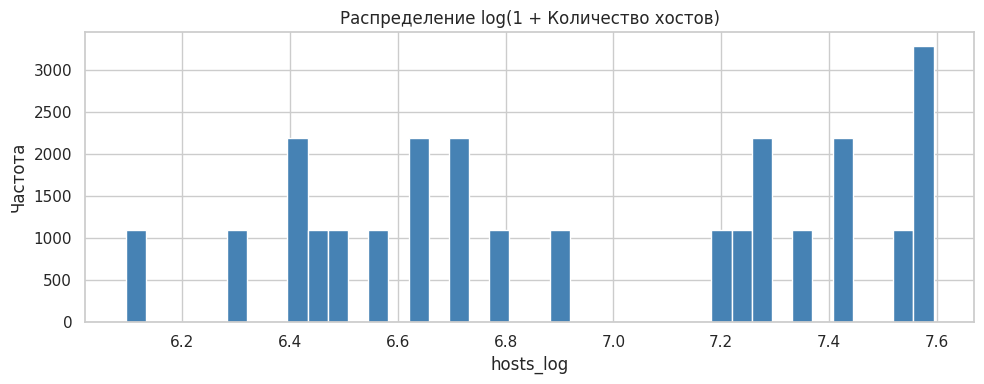

In [21]:
# Логарифмическое преобразование (log1p безопасно при 0 хостах)
dataset['hosts_log'] = np.log1p(dataset['Количество хостов'])

# Категориальный размер инфраструктуры
dataset['Размер инфраструктуры'] = pd.cut(
    dataset['Количество хостов'],
    bins=[-np.inf, 50, 200, 1000, np.inf],
    labels=['small', 'medium', 'large', 'xlarge']
).astype(str)

print("Распределение по размеру инфраструктуры:")
print(dataset['Размер инфраструктуры'].value_counts())

# Визуализация распределения log(хосты)
fig, ax = plt.subplots(figsize=(10, 4))
dataset['hosts_log'].hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Распределение log(1 + Количество хостов)')
ax.set_xlabel('hosts_log')
ax.set_ylabel('Частота')
plt.tight_layout()
plt.show()

## 15. Фильтрация строк «прогрева» (warm-up period)

Первые 7 дней наблюдений для каждого сегмента содержат неполные rolling-признаки.
Убираем их, чтобы не обучать модель на «сырых» признаках.


In [22]:
# Номер дня внутри каждого сегмента (0 = первый день наблюдений)
dataset['entity_day_number'] = dataset.groupby(
    ['infrastructure_cluster', 'threat_cluster']
).cumcount()

# Оставляем только строки, где уже прошло >= 7 дней наблюдений
dataset_model = dataset[dataset['entity_day_number'] >= 7].copy()

print(f"Размер до фильтрации: {dataset.shape}")
print(f"Размер после фильтрации: {dataset_model.shape}")
print(f"Удалено строк (warm-up): {dataset.shape[0] - dataset_model.shape[0]}")

Размер до фильтрации: (26280, 51)
Размер после фильтрации: (26112, 51)
Удалено строк (warm-up): 168


## 16. Финальный список признаков

Собираем все созданные признаки в один список.
Отдельно выделяем категориальные признаки — они передаются в CatBoost явно.


In [23]:
# Все признаки для модели
feature_cols = [

    # --- Календарные признаки (линейные) ---
    'day_of_week', 'day_of_month', 'month',

    # --- Лаговые признаки ---
   'lag_inc_1d',

    # --- Скользящие признаки ---
    'inc_3d_sum', 'inc_7d_sum', 'inc_30d_sum',
    'succ_7d_sum', 'succ_30d_sum',
    'had_incident_prev_1d', 'had_incident_prev_3d', 'had_incident_prev_7d',

    # --- Временны́е признаки (с последнего события) ---
    'days_since_last_incident', 'days_since_last_success',

    # --- Контекстные (регион + тип) ---
    'type_inc_7d_sum', 'type_inc_30d_sum',

    # --- Новые: интенсивность и тренды (для регрессии и мультикласса) ---
    'avg_inter_attack_interval',  # средний интервал между атаками
    'attack_rate_trend',          # тренд нарастания/убывания атак
    'streak_active_days',         # серия активных дней подряд
    'streak_quiet_days',          # серия тихих дней подряд
    'success_ratio_7d',           # доля успешных атак за 7 дней
    
]
# Категориальные признаки для CatBoost
cat_features = [
    'Тип предприятия',
    'Регион размещения предприятия',
    'Размер инфраструктуры'
]

print(f"Всего признаков: {len(feature_cols)}")
print(f"Категориальных: {len(cat_features)}")
print(f"\nСписок признаков:")
for f in feature_cols:
    marker = '(cat)' if f in cat_features else ''
    print(f"  - {f} {marker}")

Всего признаков: 21
Категориальных: 3

Список признаков:
  - day_of_week 
  - day_of_month 
  - month 
  - lag_inc_1d 
  - inc_3d_sum 
  - inc_7d_sum 
  - inc_30d_sum 
  - succ_7d_sum 
  - succ_30d_sum 
  - had_incident_prev_1d 
  - had_incident_prev_3d 
  - had_incident_prev_7d 
  - days_since_last_incident 
  - days_since_last_success 
  - type_inc_7d_sum 
  - type_inc_30d_sum 
  - avg_inter_attack_interval 
  - attack_rate_trend 
  - streak_active_days 
  - streak_quiet_days 
  - success_ratio_7d 


## 17. Корреляция признаков с целевой переменной

Быстрый тест: насколько каждый признак связан с target_next_24h.
Используем point-biserial correlation для числовых признаков.


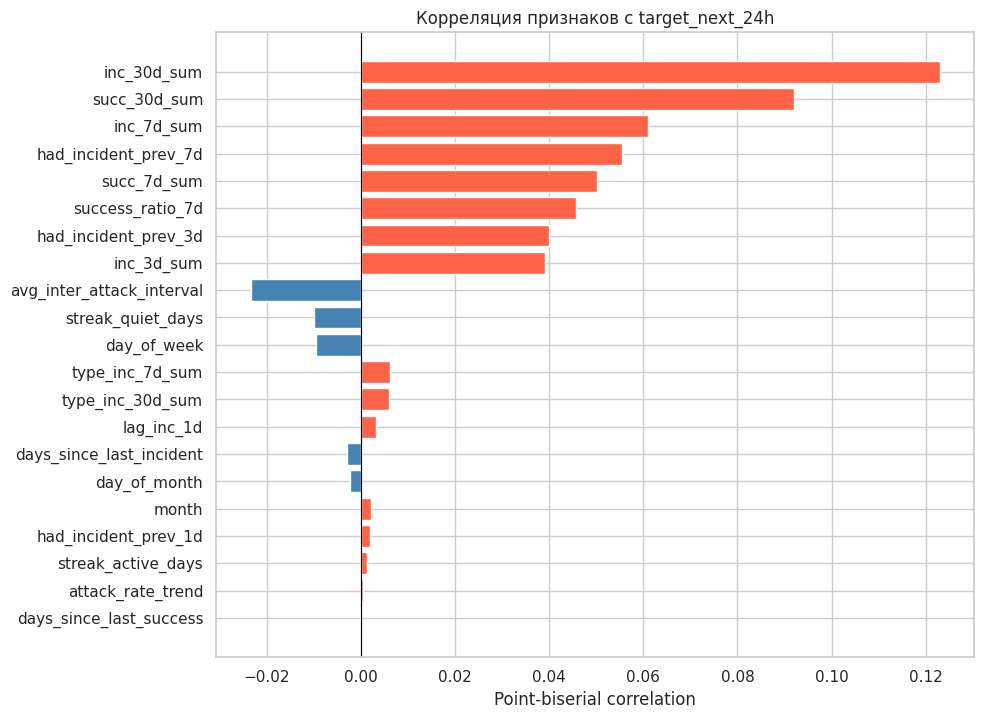

Топ-10 признаков по модулю корреляции:


,feature,correlation,pvalue
6,inc_30d_sum,0.1229,0.0000
8,succ_30d_sum,0.0921,0.0000
5,inc_7d_sum,0.0610,0.0000
11,had_incident_prev_7d,0.0554,0.0000
7,succ_7d_sum,0.0502,0.0000
20,success_ratio_7d,0.0456,0.0000
10,had_incident_prev_3d,0.0399,0.0000
4,inc_3d_sum,0.0391,0.0000
16,avg_inter_attack_interval,-0.0234,0.0002
19,streak_quiet_days,-0.0099,0.1083


In [24]:
from scipy.stats import pointbiserialr

num_features = [f for f in feature_cols if f not in cat_features]
target = 'target_next_24h'

corr_results = []
for feat in num_features:
    try:
        corr, pval = pointbiserialr(
            dataset_model[feat].fillna(0),
            dataset_model[target]
        )
        corr_results.append({'feature': feat, 'correlation': corr, 'pvalue': pval})
    except Exception:
        pass

corr_df = pd.DataFrame(corr_results).sort_values('correlation', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, max(6, len(corr_df) * 0.35)))
colors = ['tomato' if c > 0 else 'steelblue' for c in corr_df['correlation']]
ax.barh(corr_df['feature'], corr_df['correlation'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Корреляция признаков с {target}')
ax.set_xlabel('Point-biserial correlation')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Топ-10 признаков по модулю корреляции:")
display(corr_df.head(10).round(4))

## 18. Сохранение датасета

In [25]:
# Создаём директорию если нет
output_dir = Path('../data/processed')
output_dir.mkdir(parents=True, exist_ok=True)

# Сохраняем полный датасет с признаками
dataset_model.to_parquet(output_dir / 'dataset_features.parquet', index=False)

print(f"Сохранено: {output_dir / 'dataset_features.parquet'}")
print(f"Форма датасета: {dataset_model.shape}")
print(f"Признаки: {feature_cols}")

# Дополнительно сохраняем список признаков как JSON для воспроизводимости
import json
meta = {
    'feature_cols': feature_cols,
    'cat_features': cat_features,
    'target_cols': ['target_next_24h', 'target_next_7d',
                    'days_until_next_attack', 'attack_window_class'],
    'attack_window_labels': {
        '0': 'next_1d',
        '1': 'next_3d',
        '2': 'next_7d',
        '3': 'next_14d',
        '4': 'no_attack_30d'
    }
}
with open(output_dir / 'feature_meta.json', 'w') as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("Метаданные признаков сохранены: feature_meta.json")
print(f"Целевые переменные: {meta['target_cols']}")


Сохранено: ../data/processed/dataset_features.parquet
Форма датасета: (26112, 51)
Признаки: ['day_of_week', 'day_of_month', 'month', 'lag_inc_1d', 'inc_3d_sum', 'inc_7d_sum', 'inc_30d_sum', 'succ_7d_sum', 'succ_30d_sum', 'had_incident_prev_1d', 'had_incident_prev_3d', 'had_incident_prev_7d', 'days_since_last_incident', 'days_since_last_success', 'type_inc_7d_sum', 'type_inc_30d_sum', 'avg_inter_attack_interval', 'attack_rate_trend', 'streak_active_days', 'streak_quiet_days', 'success_ratio_7d']
Метаданные признаков сохранены: feature_meta.json
Целевые переменные: ['target_next_24h', 'target_next_7d', 'days_until_next_attack', 'attack_window_class']


## Итоги

Построено признаков 6 типов:

| Группа | Примеры | Логика |
|--------|---------|--------|
| Календарные | `day_of_week`, `is_weekend`, `month_sin` | Сезонность и паттерны рабочей недели |
| Лаговые | `lag_inc_1d`, `lag_success_2d` | Прямое прошлое (1–3 дня назад) |
| Rolling | `inc_7d_sum`, `succ_30d_sum` | Тренды активности (3/7/30 дней) |
| Temporal | `days_since_last_incident` | «Охлаждение» атак |
| Контекстные | `region_inc_7d_sum`, `type_inc_30d_sum` | Региональная/отраслевая волна |
| **Интенсивность** | `streak_active_days`, `success_ratio_7d`, `attack_rate_trend` | **Ритм и тренд атак** |

### Целевые переменные

| Переменная | Тип задачи | Ноутбук |
|-----------|-----------|---------|
| `target_next_24h` | Бинарная классификация | `03_model_training.ipynb` |
| `target_next_7d` | Бинарная классификация | `03_model_training.ipynb` |
| `days_until_next_attack` | **Регрессия** | `03_regression.ipynb` |
| `attack_window_class` | **Мультиклассовая классификация** | `03_multiclass.ipynb` |

**Следующие шаги:**
- `03_model_training.ipynb` — бинарная классификация
- `03_regression.ipynb` — регрессия: сколько дней до следующей атаки
- `03_multiclass.ipynb` — мультикласс: в каком временном окне ближайшая атака
